In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.feature_extraction import FeatureHasher
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
if 'ID' in df.columns:
    df = df.drop('ID',axis=1)
targer_col = 'Reached.on.Time_Y.N'
x = df.drop(targer_col, axis =1)
y = df[targer_col]

print(f"Features Shape: {x.head()}")
print(f"Target Shape: {y.tail()}")

Features Shape:   Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0               D           Flight                    4                2   
1               F           Flight                    4                5   
2               A           Flight                    2                2   
3               B           Flight                    3                3   
4               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  
0                44           1233  
1                59           3088  
2

In [4]:
x.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,D,Flight,4,2,177,3,low,F,44,1233
1,F,Flight,4,5,216,2,low,M,59,3088
2,A,Flight,2,2,183,4,low,M,48,3374
3,B,Flight,3,3,176,4,medium,M,10,1177
4,C,Flight,2,2,184,3,medium,F,46,2484


In [5]:
#ordinal feature encoding
importance_mapping={
    'low':1,
    'medium':2,
    'high':3
}
x['Product_importance']=x['Product_importance'].map(importance_mapping)
x['Product_importance'].head()

0    1
1    1
2    1
3    2
4    2
Name: Product_importance, dtype: int64

In [6]:
x['Gender'].unique()

array(['F', 'M'], dtype=object)

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
x['Gender'] = encoder.fit_transform(
    x['Gender'])

In [8]:
x['Gender'].head()

0    0
1    1
2    1
3    1
4    0
Name: Gender, dtype: int32

In [9]:
cols = ['Mode_of_Shipment', 'Warehouse_block']
combined = df[cols].astype(str).agg(' '.join, axis=1)
tokens = combined.apply(lambda x: x.split())
hasher = FeatureHasher(n_features=6, input_type='string')
hashed = hasher.transform(tokens)
hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"hash_{i}" for i in range(6)]
)

In [10]:
x= pd.concat([x, hashed_df], axis=1)
print("New shape:", x.shape)
x.head()

New shape: (10999, 16)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5
0,D,Flight,4,2,177,3,1,0,44,1233,0.0,0.0,0.0,0.0,0.0,0.0
1,F,Flight,4,5,216,2,1,1,59,3088,0.0,0.0,-2.0,0.0,0.0,0.0
2,A,Flight,2,2,183,4,1,1,48,3374,0.0,0.0,-1.0,0.0,1.0,0.0
3,B,Flight,3,3,176,4,2,1,10,1177,0.0,0.0,-2.0,0.0,0.0,0.0
4,C,Flight,2,2,184,3,2,0,46,2484,0.0,0.0,-1.0,-1.0,0.0,0.0


In [11]:
x = x.drop(['Warehouse_block', 'Mode_of_Shipment'], axis=1)

In [12]:
x.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5
0,4,2,177,3,1,0,44,1233,0.0,0.0,0.0,0.0,0.0,0.0
1,4,5,216,2,1,1,59,3088,0.0,0.0,-2.0,0.0,0.0,0.0
2,2,2,183,4,1,1,48,3374,0.0,0.0,-1.0,0.0,1.0,0.0
3,3,3,176,4,2,1,10,1177,0.0,0.0,-2.0,0.0,0.0,0.0
4,2,2,184,3,2,0,46,2484,0.0,0.0,-1.0,-1.0,0.0,0.0


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

x = pd.DataFrame(X_scaled, columns=x.columns)

In [14]:
X_scaled

array([[-0.04771132, -0.7007551 , -0.69072171, ...,  0.01269869,
        -0.4471892 ,  0.        ],
       [-0.04771132,  1.42157771,  0.12074558, ...,  0.01269869,
        -0.4471892 ,  0.        ],
       [-1.79988745, -0.7007551 , -0.56588059, ...,  0.01269869,
         2.23618996,  0.        ],
       ...,
       [ 0.82837675,  0.71413344,  0.66172378, ..., -1.90062908,
        -0.4471892 ,  0.        ],
       [ 0.82837675, -0.7007551 ,  0.26639356, ...,  0.01269869,
        -0.4471892 ,  0.        ],
       [-1.79988745,  1.42157771, -1.14847249, ...,  0.01269869,
        -0.4471892 ,  0.        ]])

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca= pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("PCA Shape:", X_pca.shape)

Original Shape: (10999, 14)
PCA Shape: (10999, 2)


In [17]:
pca.explained_variance_ratio_

array([0.14833919, 0.12336097])

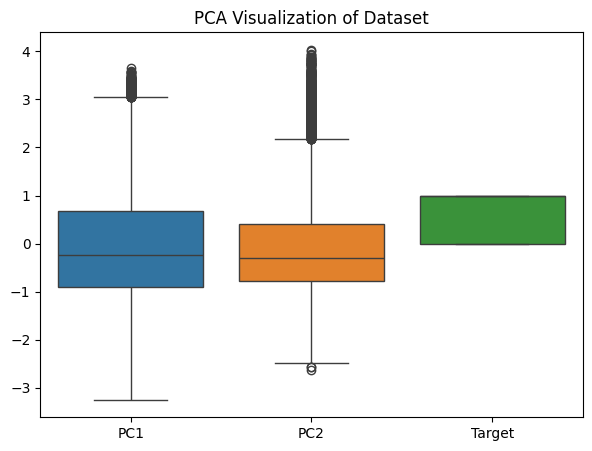

In [18]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y
plt.figure(figsize=(7,5))
sns.boxplot(data=pca_df)
plt.title("PCA Visualization of Dataset")
plt.show()

In [19]:
X_train_pca,X_test_pca,y_train,y_test=train_test_split(X_pca,y,test_size=0.2,random_state=30)

In [20]:
clf = RandomForestClassifier(n_estimators=100,
                            random_state=42)
clf.fit(X_train_pca, y_train)

RandomForestClassifier(random_state=42)

In [21]:
clf.score(X_test_pca,y_test)

0.6336363636363637

In [22]:
y_pred = clf.predict(X_test_pca)

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.58      0.56       874
           1       0.71      0.67      0.69      1326

    accuracy                           0.63      2200
   macro avg       0.62      0.63      0.62      2200
weighted avg       0.64      0.63      0.64      2200

